# Feature-axis validation — is `design_name` really the right client axis?

Systematic re-check of the Phase-2/3 conclusion. Build size-invariant per-sample
descriptors, then run PCA + label-free clustering + probes + variance
decomposition against every metadata factor. Whichever factor consistently
explains the layout structure earns the FL client axis; if something else
(e.g. the `-a`/`-b` variant, macro geometry, or a flow attribute in disguise)
explains more, that's the honest partition axis.

## Predictions (frozen before running anything)

1. **PC1 ≈ macro / channel geometry** (macro-area fraction, distance-transform
   median of free space). Splits `-a` from `-b` almost perfectly.
2. **PC2 ≈ design scale**, ordering zero-riscy → RISCY → RISCY-FPU.
3. **Utilization** appears as a *smooth gradient*, not clusters.
4. **Power mesh** is near-invisible in routability features (would only show up
   in IR-drop channels, which the DRC feature set does not carry).
5. **Macro placement** sits between design and flow: enough spatial effect to
   move a point, not enough to redefine the cluster.
6. **K-means on the first 3 PCs** will pick a small K (2–6) whose clusters
   line up with `core` / `variant` and secondarily with `utilization` —
   not with `power_mesh` or `filler_insertion`.

If any diagnostic contradicts the list, that is a finding — not a signal to
re-tune the pipeline.

## Workflow

1. Parse filenames into a factorial design matrix (already covered in the
   feature-analysis notebooks — repeated inline).
2. Stratified subsample: `N_PER_STRATUM` samples per
   (design × clock × utilization) cell so descriptor extraction stays cheap.
3. Build a ~80-descriptor vector per sample (distributional + textural +
   macro-geometry + anisotropy). QuantileTransform + StandardScaler.
4. PCA first, UMAP only as decoration. Recolor the same PC1/PC2 six times.
5. **K-means clustering** on the first 3 PCs, `K` selected by highest mean
   silhouette. Visualise the chosen partition in 3D PC1/PC2/PC3 space.
6. **Describe each PC from its signed loadings** — which mixture of factors
   and design-family indicators the axis actually encodes.
7. **Cluster-quality description** — for each K-means cluster: size, numeric
   centroid, categorical mode + purity, and cluster × factor cross-tabs, so
   every cluster gets a plain-English EDA persona.
8. Quantify with kNN label agreement, probe AUC under GroupKFold, and
   variance-weighted η² decomposition on the leading PCs.
9. One guard — label-shuffle control on the top-ranked factors.
10. Final verdict cell: does `design_name` win every diagnostic (including
    the k-means personas), or does another factor take one?

# Imports

In [2]:
import os, sys, warnings
from collections import Counter
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from scipy import stats as scipy_stats
from scipy.ndimage import label as ndi_label, distance_transform_edt
from scipy.stats import skew as scipy_skew

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
CHANNEL_NAMES = [
    'macro_region', 'cell_density',
    'RUDY_long', 'RUDY_short', 'RUDY_pin_long',
    'congestion_eGR_H', 'congestion_eGR_V',
    'congestion_GR_H',  'congestion_GR_V',
]
SEED = 42
N_PER_STRATUM = 12          # samples per (design x clock x util) cell
STRATUM_COLS  = ['design_name','clock_ns','utilization']
print('Imports OK.')

Imports OK.


# Parse filenames → factorial design matrix

Adds two derived columns beyond the standard parser:

- `core` — the design family with the `-a`/`-b` suffix stripped
  (`RISCY-a` → `RISCY`).
- `variant` — the stripped suffix (`a`, `b`, or `n/a`).

This lets the probes measure the `-a` vs `-b` axis independently of the
design axis, which is exactly the split the physical-design engineer cares
about.

In [3]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    return {
        'design_name':      '-'.join(parts[:-6]),
        'macro_count':      parts[-6],
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

def _split_variant(dn):
    for suf in ('-a','-b'):
        if dn.endswith(suf):
            return dn[:-2], suf[1:]
    return dn, 'n/a'
cv = df_meta['design_name'].map(_split_variant)
df_meta['core']    = cv.map(lambda t: t[0])
df_meta['variant'] = cv.map(lambda t: t[1])

FACTOR_COLS = ['design_name','core','variant','macro_count','clock_ns',
               'utilization','macro_placement','power_mesh','filler_insertion']
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')
print()
print(df_meta[FACTOR_COLS].head())

Samples: 10242
Unique-value counts per factor:
  design_name            6
  core                   3
  variant                2
  macro_count            3
  clock_ns               3
  utilization            5
  macro_placement        4
  power_mesh             8
  filler_insertion       2

    design_name        core variant macro_count  clock_ns  utilization  \
0       RISCY-a       RISCY       a           1       2.0         0.70   
1       RISCY-a       RISCY       a           1       2.0         0.70   
2       RISCY-a       RISCY       a           1       2.0         0.85   
3       RISCY-a       RISCY       a           2       5.0         0.75   
4  zero-riscy-b  zero-riscy       b           3       2.0         0.85   

  macro_placement power_mesh filler_insertion  
0               1          1                0  
1               2          2                0  
2               2          3                0  
3               2          1                0  
4               1       

# Stratified subsample

`N_PER_STRATUM` samples per (design × clock × utilization). Ensures every
cell of the design × persona grid is represented so the probes and
variance-decomposition are not confounded by unbalanced counts. On N28's
6 × 3 × 5 = 90 strata this gives ~1000 samples — enough for stable
descriptors, cheap enough to iterate.

In [9]:
def _sample(g, k=N_PER_STRATUM, seed=SEED):
    return g.sample(n=min(k, len(g)), random_state=seed)

subset = (df_meta
          .groupby(STRATUM_COLS, group_keys=False)
          .apply(_sample)
          .reset_index(drop=True))
print(f'Subsample: {len(subset)} samples over '
      f'{subset[STRATUM_COLS].drop_duplicates().shape[0]} strata')
print(subset.groupby(STRATUM_COLS).size().describe())

display(subset.head())
print(subset.shape)

Subsample: 1080 samples over 90 strata
count    90.0
mean     12.0
std       0.0
min      12.0
25%      12.0
50%      12.0
75%      12.0
max      12.0
dtype: float64


,design_name,macro_count,clock_ns,utilization,macro_placement,power_mesh,filler_insertion,filename,core,variant
0,RISCY-FPU-a,2,2.0,0.7,1,6,1,4706-RISCY-FPU-a-2-c2-u0.7-m1-p6-f1.npy,RISCY-FPU,a
1,RISCY-FPU-a,3,2.0,0.7,2,4,1,5336-RISCY-FPU-a-3-c2-u0.7-m2-p4-f1.npy,RISCY-FPU,a
2,RISCY-FPU-a,1,2.0,0.7,1,4,1,4011-RISCY-FPU-a-1-c2-u0.7-m1-p4-f1.npy,RISCY-FPU,a
3,RISCY-FPU-a,1,2.0,0.7,1,2,1,4009-RISCY-FPU-a-1-c2-u0.7-m1-p2-f1.npy,RISCY-FPU,a
4,RISCY-FPU-a,3,2.0,0.7,3,4,0,5232-RISCY-FPU-a-3-c2-u0.7-m3-p4-f0.npy,RISCY-FPU,a


(1080, 10)


# Preprocess + PCA
`QuantileTransformer` on each column (heavy-tailed IR / congestion
distributions otherwise dominate every PC) followed by `StandardScaler`,
then a 10-component PCA. We keep the first 10 PCs regardless of
explained-variance elbow because the variance-decomposition below needs
the same fixed set of PCs across every factor to be comparable."

Index(['macro_count', 'clock_ns', 'utilization', 'macro_placement',
       'power_mesh', 'filler_insertion', 'core_RISCY', 'core_RISCY-FPU',
       'core_zero-riscy', 'variant_a', 'variant_b'],
      dtype='object')
(1080, 11) (1080, 11) (1080, 11) 11
Index([], dtype='object')
Explained variance ratio:
  PC 1: 0.192   cumulative=0.192
  PC 2: 0.142   cumulative=0.334
  PC 3: 0.137   cumulative=0.471
  PC 4: 0.113   cumulative=0.583
  PC 5: 0.100   cumulative=0.683
  PC 6: 0.092   cumulative=0.775
  PC 7: 0.090   cumulative=0.865
  PC 8: 0.070   cumulative=0.935
  PC 9: 0.065   cumulative=1.000
  PC10: 0.000   cumulative=1.000


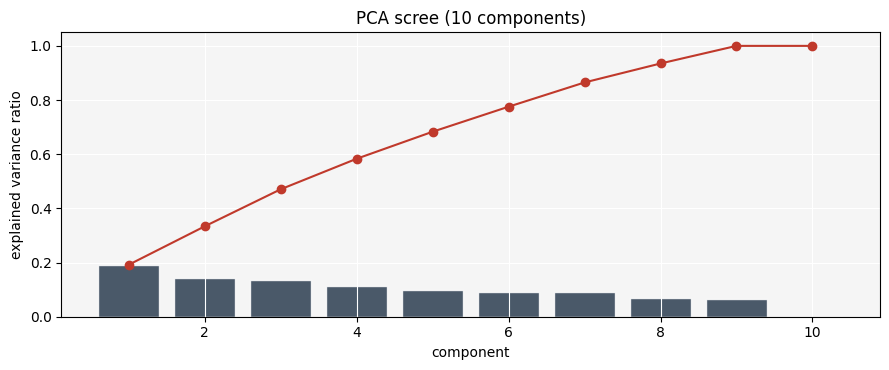

In [45]:
stale = [c for c in subset.columns if c.startswith(('core_', 'variant_', 'core', 'variant'))]
subset = subset.drop(columns=stale)

parts = subset['design_name'].str.rsplit('-', n=1, expand=True)
subset['core'] = parts[0]      # RISCY, RISCY-FPU, zero-riscy
subset['variant'] = parts[1]   # a, b

new_subset = pd.get_dummies(subset, columns=['core', 'variant'], dtype='uint8')
new_subset = new_subset.drop(columns=['design_name', 'filename'])

print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

""" qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
print(X_qt.shape) """
sc = StandardScaler()
X_std = sc.fit_transform(X)

print(new_subset.shape, X.shape, X_std.shape, sc.n_features_in_)
print(new_subset.columns[new_subset.columns.duplicated(keep=False)])

pca = PCA(n_components=10, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, 11), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, 11), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (10 components)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2 scatter

First: print the top-10 descriptors by absolute loading on PC1/PC2/PC3.
If the story lines up with the prediction (PC1 dominated by macro-geometry
descriptors, PC2 by scale-like ones), the manifold learner is decoration.

Second: the same PC1/PC2 scatter recolored by six metadata factors. A
factor that produces visibly separated clusters in the PC1/PC2 view is
one that the descriptors encode directly."

(11, 10)


Top-10 |loadings| on PC1:
  +0.660  variant_a
  -0.660  variant_b
  +0.266  macro_placement
  -0.226  filler_insertion
  +0.054  core_RISCY
  -0.040  utilization
  -0.035  core_RISCY-FPU
  -0.032  clock_ns
  -0.019  core_zero-riscy
  -0.016  macro_count

Top-10 |loadings| on PC2:
  +0.748  core_RISCY
  -0.415  core_RISCY-FPU
  -0.333  core_zero-riscy
  -0.302  filler_insertion
  -0.125  variant_a
  +0.125  variant_b
  +0.111  macro_placement
  -0.103  macro_count
  -0.074  utilization
  +0.070  power_mesh

Top-10 |loadings| on PC3:
  +0.733  core_zero-riscy
  -0.671  core_RISCY-FPU
  -0.062  core_RISCY
  +0.061  macro_placement
  -0.058  macro_count
  +0.020  power_mesh
  +0.016  filler_insertion
  +0.015  variant_b
  -0.015  variant_a
  +0.002  utilization


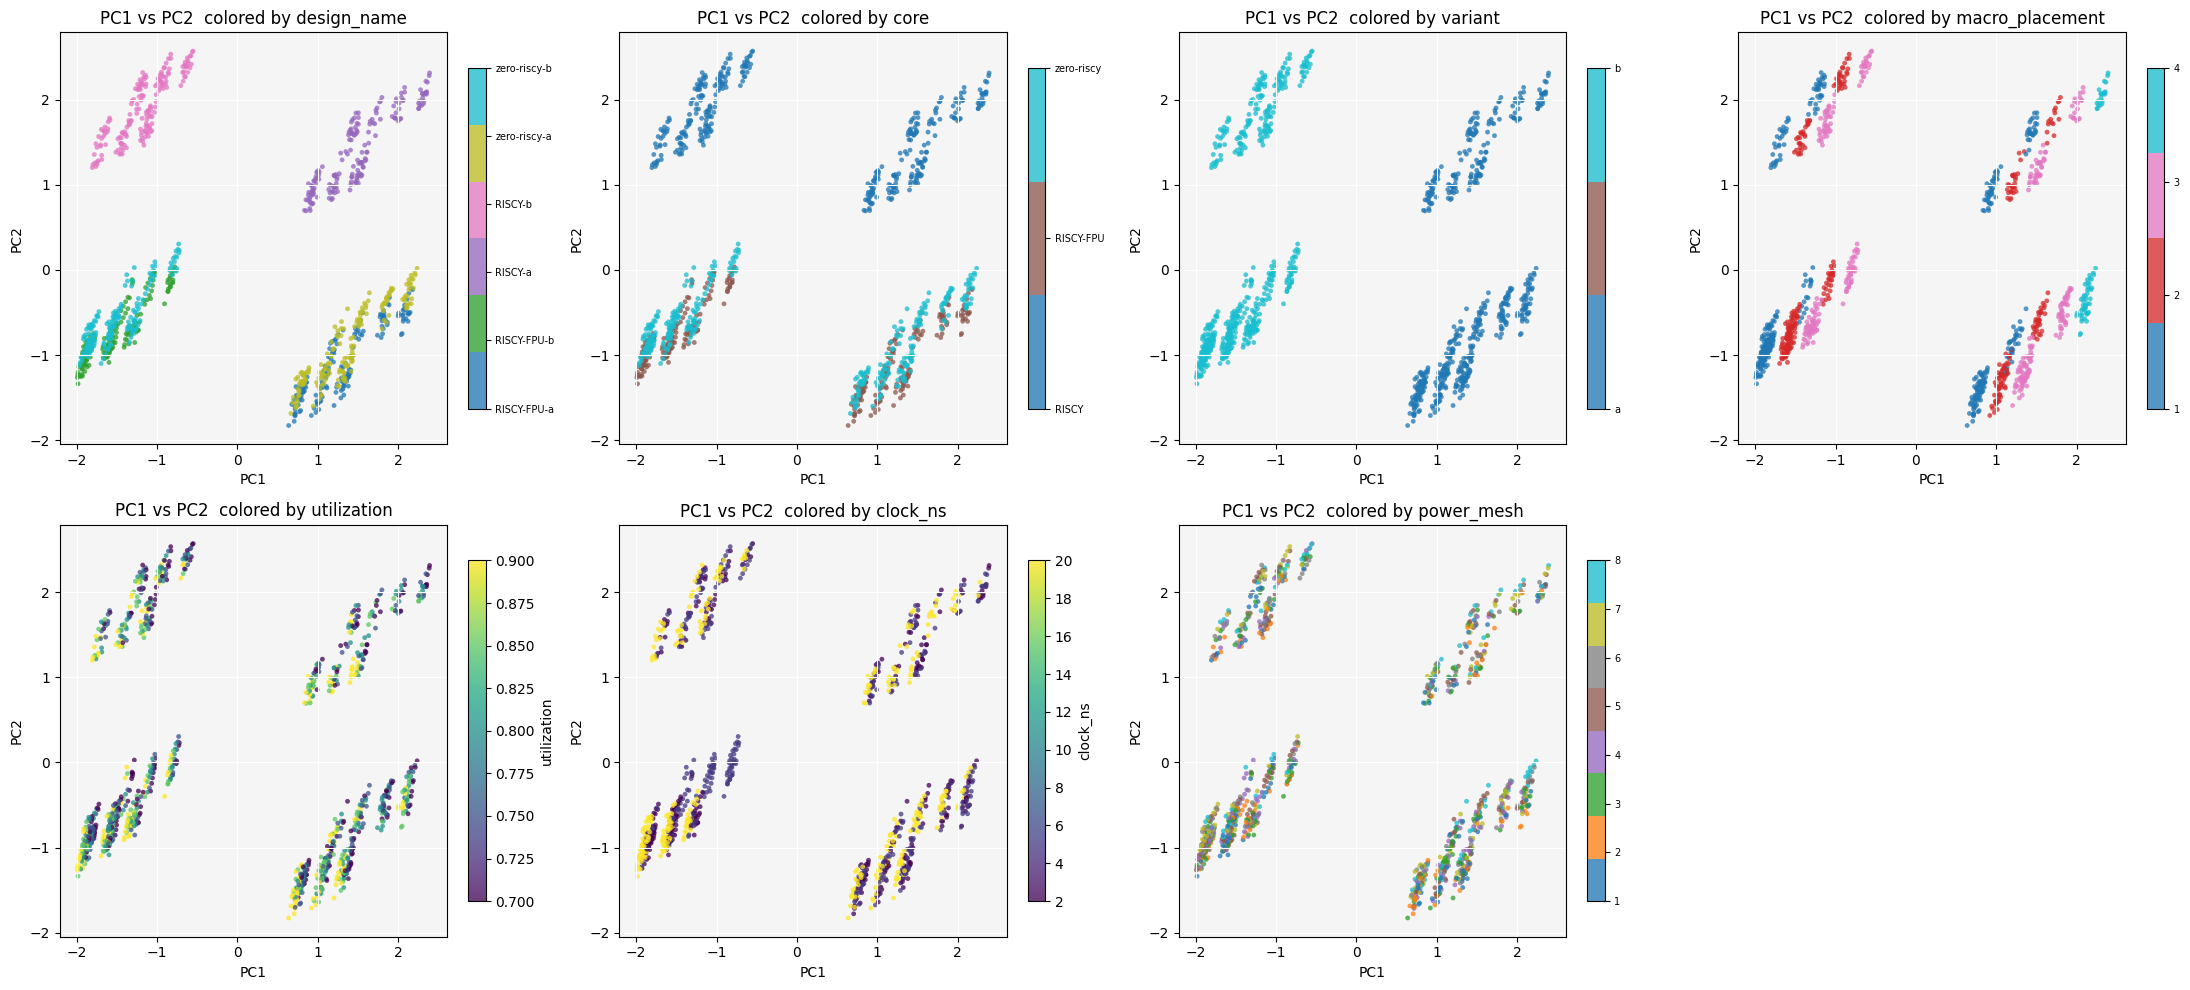

In [48]:
display(pca.components_.T.shape)

loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name','core','variant','macro_placement',
                   'utilization','clock_ns','power_mesh']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, factor in zip(axes.ravel(), recolor_factors):
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap='viridis',
                         s=12, alpha=0.75, edgecolor='none')
        plt.colorbar(sc_, ax=ax, fraction=0.04, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap=cmap,
                         s=12, alpha=0.75, edgecolor='none',
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)), fraction=0.04)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 vs PC2  colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

df_full = subset

# K-means clustering — select K by silhouette score

Cluster the samples in the first-3-PC subspace, sweep `K` from 2 to 15, and
pick the `K` with the highest mean silhouette score. Silhouette rewards
tight, well-separated clusters and is independent of any metadata label, so
it lets the descriptor structure — not our factor guesses — decide the
natural granularity.

The inertia (elbow) curve is shown alongside as a sanity check: the two
criteria should broadly agree on the plateau region.

In [ ]:
from sklearn.metrics import silhouette_score

Z3 = Z[:, :3]  # cluster in the space we visualise below

K_MIN, K_MAX = 2, 15
sil_scores = []
inertias   = []
km_models  = {}
for k in range(K_MIN, K_MAX + 1):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil = silhouette_score(Z3, lab)
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    km_models[k] = (km, lab)
    print(f'  K={k:2d}  silhouette={sil:.4f}  inertia={km.inertia_:.1f}')

best_k   = int(np.array(range(K_MIN, K_MAX + 1))[np.argmax(sil_scores)])
best_sil = max(sil_scores)
print(f'\nBest K by silhouette: K={best_k}  silhouette={best_sil:.4f}')

kmeans_best, cluster_labels = km_models[best_k]
df_full = df_full.copy()
df_full['cluster'] = cluster_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ks = list(range(K_MIN, K_MAX + 1))
ax1.plot(ks, sil_scores, marker='o', color='#2980b9')
ax1.axvline(best_k, color='#c0392b', linestyle='--', alpha=0.7,
            label=f'best K = {best_k}')
ax1.set_xlabel('K'); ax1.set_ylabel('silhouette score')
ax1.set_title('Silhouette vs K (first 3 PCs)')
ax1.legend()
ax2.plot(ks, inertias, marker='s', color='#2c3e50')
ax2.axvline(best_k, color='#c0392b', linestyle='--', alpha=0.7)
ax2.set_xlabel('K'); ax2.set_ylabel('inertia')
ax2.set_title('Inertia (elbow) vs K')
plt.tight_layout(); plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

cmap_c = mcm.get_cmap('tab10' if best_k <= 10 else 'tab20', best_k)
fig = plt.figure(figsize=(15, 6))

ax3d = fig.add_subplot(1, 2, 1, projection='3d')
for c in range(best_k):
    m = cluster_labels == c
    ax3d.scatter(Z[m, 0], Z[m, 1], Z[m, 2],
                 color=cmap_c(c), s=18, alpha=0.75,
                 edgecolor='none', label=f'C{c}  (n={int(m.sum())})')
ax3d.set_xlabel(f'PC1 ({evr[0]:.2f})')
ax3d.set_ylabel(f'PC2 ({evr[1]:.2f})')
ax3d.set_zlabel(f'PC3 ({evr[2]:.2f})')
ax3d.set_title(f'K-means (K={best_k}) in PC1/PC2/PC3 space')
ax3d.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.05, 1))

ax2d = fig.add_subplot(1, 2, 2)
for c in range(best_k):
    m = cluster_labels == c
    ax2d.scatter(Z[m, 0], Z[m, 1], color=cmap_c(c),
                 s=18, alpha=0.75, edgecolor='none',
                 label=f'C{c}')
ax2d.set_xlabel('PC1'); ax2d.set_ylabel('PC2')
ax2d.set_title('PC1 vs PC2 (top-down view)')
ax2d.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Describing PC1 / PC2 / PC3 from loadings

For each of the first three principal components, print the signed loadings
of every input descriptor and rank them by magnitude. This says *which
mixture of design factors and design-family indicators* the PC represents.

Reading rules:

- **Positive vs negative loadings**: the PC contrasts descriptors on one
  side against those on the other. A PC with `+utilization` and
  `-clock_ns` is a *dense-and-fast* axis, for example.
- **Magnitude**: larger |loading| = the input drives more of that PC.
- **Isolated one-hot loadings** (`core_*` / `variant_*`): the PC largely
  encodes a categorical design distinction rather than a continuous knob.

In [ ]:
loadings_top3 = loadings[['PC1', 'PC2', 'PC3']].copy()

for pc in ['PC1', 'PC2', 'PC3']:
    print(f'\n=== {pc} (explained variance = {evr[int(pc[-1]) - 1]:.3f}) ===')
    ranked = loadings_top3[pc].sort_values(ascending=False)
    print('  Positive side (top of axis):')
    for name, v in ranked.head(6).items():
        print(f'    {v:+.3f}  {name}')
    print('  Negative side (bottom of axis):')
    for name, v in ranked.tail(6).items():
        print(f'    {v:+.3f}  {name}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    s = loadings[pc].sort_values()
    colors = ['#c0392b' if v < 0 else '#2980b9' for v in s.values]
    ax.barh(s.index, s.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{pc}  (evr={evr[int(pc[-1]) - 1]:.2f})')
    ax.set_xlabel('loading')
plt.tight_layout(); plt.show()

# Cluster quality — describing each discovered persona

For every K-means cluster we report:

1. **Size and share** of the subsample.
2. **Numeric-factor means** (clock_ns, utilization) — the centroid of the
   cluster in the human-readable factor space.
3. **Categorical-factor mode** (design_name, macro_placement, power_mesh,
   filler_insertion) — the level that dominates the cluster.
4. **Purity per factor** — fraction of the cluster taken by its dominant
   level. High purity ⇒ the cluster IS that persona; low purity ⇒ the
   cluster mixes several personas along that axis.

This is the cluster-level analogue of the kNN-purity table below; it
translates the k-means grouping into a physical EDA description
('cluster 0 is small, low-frequency zero-riscy-a; cluster 3 is
high-utilisation FPU', etc.).

In [ ]:
num_cols = ['clock_ns', 'utilization']
cat_cols = ['design_name', 'core', 'variant', 'macro_count',
            'macro_placement', 'power_mesh', 'filler_insertion']

summary_rows = []
for c in sorted(df_full['cluster'].unique()):
    sub = df_full[df_full['cluster'] == c]
    row = {
        'cluster': f'C{c}',
        'n':       len(sub),
        'share':   round(len(sub) / len(df_full), 3),
    }
    for nc in num_cols:
        row[f'{nc}_mean'] = round(float(sub[nc].mean()), 3)
    for cc in cat_cols:
        vc  = sub[cc].astype(str).value_counts()
        top = vc.index[0]
        row[f'{cc}_top']    = top
        row[f'{cc}_purity'] = round(float(vc.iloc[0] / len(sub)), 3)
    summary_rows.append(row)
cluster_summary = pd.DataFrame(summary_rows)
print('Cluster-level summary:')
print(cluster_summary.to_string(index=False))

print('\nCross-tab: cluster x design_name (counts)')
xt_design = pd.crosstab(df_full['cluster'], df_full['design_name'])
print(xt_design.to_string())

print('\nCross-tab: cluster x utilization (counts)')
xt_util = pd.crosstab(df_full['cluster'], df_full['utilization'])
print(xt_util.to_string())

print('\nCross-tab: cluster x clock_ns (counts)')
xt_clock = pd.crosstab(df_full['cluster'], df_full['clock_ns'])
print(xt_clock.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (title, xt) in zip(axes, [
        ('cluster x design_name', xt_design),
        ('cluster x utilization', xt_util),
        ('cluster x clock_ns',    xt_clock),
]):
    xt_norm = xt.div(xt.sum(axis=1), axis=0)
    xt_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab20',
                 edgecolor='white', width=0.8)
    ax.set_title(f'{title} (row-normalised)')
    ax.set_ylabel('fraction'); ax.set_xlabel('cluster')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

# Quantify — kNN label agreement (descriptor space)

For each factor, take a point's 15 nearest neighbours in the standardized
descriptor space and report the fraction that share its label. Compare to
chance = `1 / n_levels`. Robust, cluster-assumption-free. Ranking by
`lift = purity − chance` is the honest way to compare factors with
different numbers of levels."

          factor  n_levels  chance  knn_purity@15  lift
     design_name         6   0.167          1.000 0.833
            core         3   0.333          1.000 0.667
         variant         2   0.500          1.000 0.500
filler_insertion         2   0.500          0.954 0.454
        clock_ns         3   0.333          0.672 0.339
     macro_count         3   0.333          0.646 0.313
 macro_placement         4   0.250          0.543 0.293
     utilization         5   0.200          0.336 0.136
      power_mesh         8   0.125          0.229 0.104


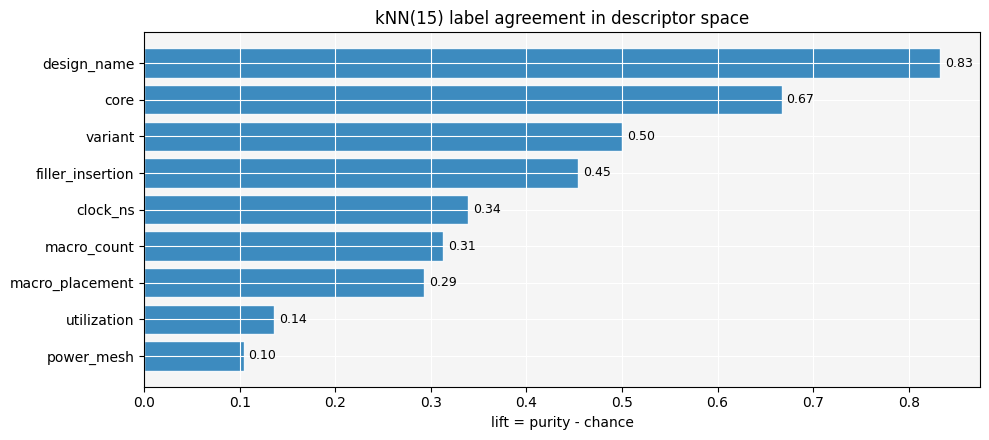

In [49]:
def knn_purity(X_, labels, k=15):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_)
    _, idx = nn.kneighbors(X_)
    idx = idx[:, 1:]  # drop self-neighbour
    agree = np.zeros(len(labels))
    for i in range(len(labels)):
        neigh = labels[idx[i]]
        agree[i] = (neigh == labels[i]).mean()
    return float(agree.mean())


purity_rows = []
for f in FACTOR_COLS:
    lab = df_full[f].astype(str).to_numpy()
    n_lvl = len(set(lab))
    if n_lvl < 2:
        continue
    chance = 1.0 / n_lvl
    p = knn_purity(X_std, lab, k=15)
    purity_rows.append({
        'factor':          f,
        'n_levels':        n_lvl,
        'chance':          round(chance, 3),
        'knn_purity@15':   round(p, 3),
        'lift':            round(p - chance, 3),
    })
purity_df = pd.DataFrame(purity_rows).sort_values('lift', ascending=False)
print(purity_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(purity_df['factor'], purity_df['lift'], color='#2980b9',
        alpha=0.9, edgecolor='white')
ax.invert_yaxis()
for i, v in enumerate(purity_df['lift']):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('lift = purity - chance')
ax.set_title('kNN(15) label agreement in descriptor space')
plt.tight_layout(); plt.show()

# Probe AUC under `GroupKFold`

Two probes per factor (logistic regression and gradient boosting) with
3-fold `GroupKFold`. `groups = design_name` prevents the trivial leakage\n",
where two samples of the same design end up in both train and test — that\n",
leakage would report ~0.99 AUC on every factor and mean nothing.\n",
\n",
For factors that **are** design (design_name / core / variant), a plain
design-group would leave a fold with only one class, so we fall back to\n",
grouping on `design_name × macro_placement` (~18 groups) instead. AUC is\n",
reported as macro-average one-vs-rest for multi-class targets."

In [50]:
def probe_auc(X_, y, groups, model_name='logit', k=3):
    if model_name == 'logit':
        model = LogisticRegression(max_iter=1000, multi_class='ovr')
    else:
        model = GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                           random_state=SEED)
    n_groups = len(set(groups))
    k = min(k, n_groups)
    if k < 2:
        return float('nan'), float('nan')
    gkf = GroupKFold(n_splits=k)
    aucs = []
    for tr, te in gkf.split(X_, y, groups):
        try:
            model.fit(X_[tr], y[tr])
            proba = model.predict_proba(X_[te])
            classes = np.unique(y[tr])
            if len(classes) < 2 or len(np.unique(y[te])) < 2:
                continue
            if proba.shape[1] == 2:
                aucs.append(roc_auc_score(y[te], proba[:, 1]))
            else:
                aucs.append(roc_auc_score(y[te], proba, multi_class='ovr',
                                          average='macro', labels=classes))
        except Exception:
            continue
    if not aucs:
        return float('nan'), float('nan')
    return float(np.mean(aucs)), float(np.std(aucs))


groups_default = df_full['design_name'].astype(str).to_numpy()
groups_alt     = (df_full['design_name'].astype(str) + '|'
                  + df_full['macro_placement'].astype(str)).to_numpy()

probe_rows = []
for f in FACTOR_COLS:
    y = df_full[f].astype(str).to_numpy()
    if len(set(y)) < 2:
        continue
    groups = groups_alt if f in ('design_name', 'core', 'variant') else groups_default
    m_lg, s_lg = probe_auc(X_std, y, groups, 'logit', k=3)
    m_gb, s_gb = probe_auc(X_std, y, groups, 'gbm',   k=3)
    probe_rows.append({
        'factor':    f,
        'n_levels':  len(set(y)),
        'logit_AUC': round(m_lg, 3), 'logit_std': round(s_lg, 3),
        'gbm_AUC':   round(m_gb, 3), 'gbm_std':   round(s_gb, 3),
    })
probe_df = pd.DataFrame(probe_rows).sort_values('gbm_AUC', ascending=False)
print(probe_df.to_string(index=False))

          factor  n_levels  logit_AUC  logit_std  gbm_AUC  gbm_std
            core         3      1.000      0.000      1.0      0.0
         variant         2      1.000      0.000      1.0      0.0
     macro_count         3      0.998      0.003      1.0      0.0
        clock_ns         3      0.996      0.005      1.0      0.0
     utilization         5      0.997      0.001      1.0      0.0
 macro_placement         4      0.997      0.003      1.0      0.0
      power_mesh         8      0.891      0.017      1.0      0.0
filler_insertion         2      1.000      0.000      1.0      0.0
     design_name         6        NaN        NaN      NaN      NaN


# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), we compute
per-PC η² of each factor via one-way ANOVA and sum the contributions
weighted by that PC's explained variance. The `weighted_total` column\n",
approximates *fraction of layout variance explained by that factor*.\n",
Balanced design ⇒ these numbers can be read semi-quantitatively.\n",
\n",
This is the single most informative output for the client-axis question:\n",
whichever factor tops `weighted_total` is the axis the descriptors are\n",
actually structured by."

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  weighted_total
     design_name         6     0.928     0.902     0.995     0.155     0.003     0.004     0.006     0.010     0.016      0.002           0.463
            core         3     0.006     0.876     0.995     0.103     0.001     0.004     0.004     0.000     0.011      0.000           0.275
         variant         2     0.920     0.024     0.000     0.044     0.001     0.000     0.001     0.008     0.001      0.000           0.186
 macro_placement         4     0.199     0.019     0.006     0.324     0.003     0.007     0.043     0.375     0.137      0.002           0.118
filler_insertion         2     0.108     0.142     0.000     0.316     0.001     0.007     0.000     0.005     0.421      0.000           0.105
     macro_count         3     0.006     0.019     0.014     0.178     0.518     0.000     0.021     0.193     0.075      0.004         

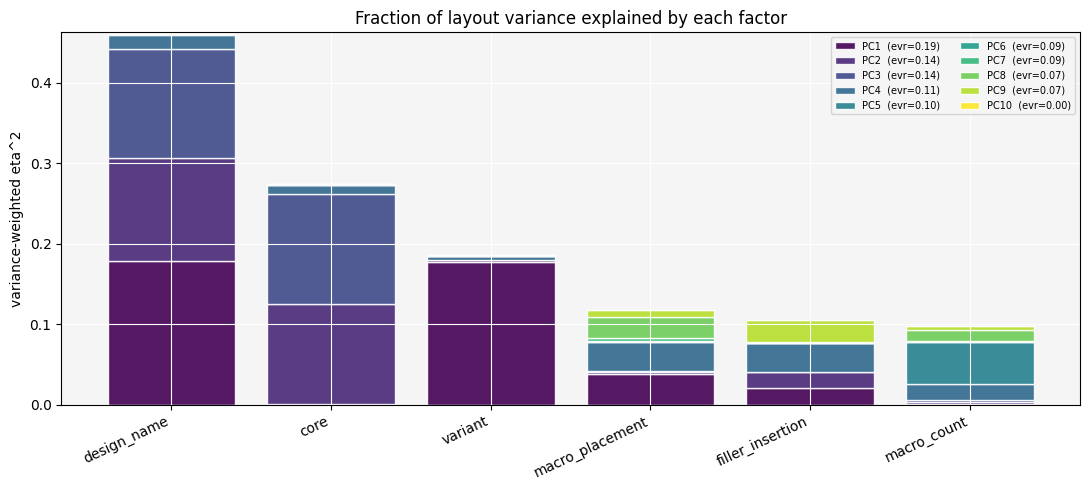

In [51]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Guards

Two negative controls without which every AUC number above is
meaningless.

- **Label-shuffle**: permutes labels for the two most-separable factors\n",
  and refits. Must collapse to chance (~1/n_classes). If it doesn't,\n",
  either the group-splitting is broken or the AUC estimator is."

In [53]:
print('\nlabel-shuffle control (should collapse to chance):')
rng2 = np.random.default_rng(SEED + 7)
for f in ['design_name', 'variant', 'utilization']:
    y = df_full[f].astype(str).to_numpy()
    y_perm = rng2.permutation(y)
    groups = groups_alt if f in ('design_name', 'core', 'variant') else groups_default
    m, _ = probe_auc(X_std, y_perm, groups, 'gbm', k=3)
    print(f'  shuffled {f:15s} AUC = {m:.3f}   chance = {1.0 / len(set(y)):.3f}')


label-shuffle control (should collapse to chance):
  shuffled design_name     AUC = 0.493   chance = 0.167
  shuffled variant         AUC = 0.485   chance = 0.500
  shuffled utilization     AUC = 0.515   chance = 0.200


# Verdict — decide the client axis from the diagnostics

Read the five diagnostics *together* — no single number decides:

1. **Variance decomposition** (`eta_df.weighted_total`) — fraction of
   layout variance the factor explains. This is the primary evidence.
2. **Probe AUC under GroupKFold** — how learnable the factor is from the
   descriptors, with leakage suppressed.
3. **kNN purity lift** — nearest-neighbour agreement in descriptor space.
4. **K-means cluster personas** (`cluster_summary`, `xt_design`, `xt_util`,
   `xt_clock`) — the label-free grouping picked by silhouette. If the
   clusters map cleanly onto one factor (high `*_purity`, one-hot
   cross-tab rows), that factor IS the natural axis. If clusters mix
   several designs / utilisations evenly, no factor owns the structure.
5. **PC loadings interpretation** — sanity check that PC1/PC2/PC3 are
   dominated by the factors the other diagnostics highlight (not by a
   nuisance descriptor).

Decision rule (write the ranking BEFORE reading the guards):

- **`design_name` wins if** it tops variance decomposition AND either
  probe AUC or kNN lift, AND the K-means clusters have high
  `design_name_purity` (the personas ARE designs), AND the shuffle
  control collapses to chance.
- **Switch to a finer axis** (e.g. `variant`, or `design_name × variant`)
  **if** `variant` gets a comparable or higher weighted-η² AND the
  k-means clusters split each design into its `-a`/`-b` sub-personas.
  That would mean the `-a`/`-b` split is the physical signal and
  `design_name` was only a coarser proxy.
- **Switch to a coarser axis** (e.g. `core`) if `variant` is invisible in
  both η² and cluster composition, and `core` explains most of the
  variance — indicates the `-a`/`-b` variants are essentially
  interchangeable in feature space and k-means merges them.
- **Drop the physical-design axis entirely** if a flow attribute
  (`macro_placement`, `power_mesh`) explains more of the variance than
  any design column AND dominates the k-means cluster purities — that
  would flip Phase 2's ownership decision.

Any of those outcomes is a valid answer; the point of this notebook is
that you commit to the rule before looking at the plots, and now you
have both a label-free (k-means) and a label-supervised (probes, η²)
line of evidence pointing at the same axis — or not.